In [1]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import re
import nltk
import string
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# читаем данные из CSV-файла
df = pd.read_csv('reviews.csv', encoding='utf-8', sep='\t')
df.head() # вывод первых 5 строк из датафрейма

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


In [3]:
#предобработка датасета
df['cleaned_reviews'] = df['review'].str.lower() # приведение к нижнему регистру
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'[^\w\s]','', regex=True) # удаление пунктуации
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'\d+', '', regex=True) # удаление чисел

# удаление стоп-слов
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('russian'))
def stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
df["cleaned_reviews"] = df["cleaned_reviews"].apply(stopwords)

# удаление эмодзи
def emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)
df['cleaned_reviews'] = df['cleaned_reviews'].apply(emoji)

# удалениe URL
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove_urls)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",negative,товар отдали другому человеку получила посылку...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,товар пришел продавец продлил защиту моего сог...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [4]:
# токенизация предобработанного текста
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

def tokenize_text(text):
    return nltk.word_tokenize(text)

# сохраним токены (списки слов) в отдельной колонке tokenized_text
df['tokenized_text'] = df['cleaned_reviews'].apply(tokenize_text)
df.head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review,sentiment,cleaned_reviews,tokenized_text
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный горловина напере...,"[качество, плохое, пошив, ужасный, горловина, ..."
1,"Товар отдали другому человеку, я не получила п...",negative,товар отдали другому человеку получила посылку...,"[товар, отдали, другому, человеку, получила, п..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл..."
3,"товар не пришел, продавец продлил защиту без м...",negative,товар пришел продавец продлил защиту моего сог...,"[товар, пришел, продавец, продлил, защиту, мое..."
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]"


In [5]:
# лемматизация текста
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

# функция для лемматизации списка токенов
def lemmatize_tokens(tokens):
    if not isinstance(tokens, list):
        return tokens
    return [morph.parse(word)[0].normal_form for word in tokens]

# запишем результат в новый столбец lemmatized_text
df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_tokens)
df.head()

,review,sentiment,cleaned_reviews,tokenized_text,lemmatized_text
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный горловина напере...,"[качество, плохое, пошив, ужасный, горловина, ...","[качество, плохой, пошив, ужасный, горловина, ..."
1,"Товар отдали другому человеку, я не получила п...",negative,товар отдали другому человеку получила посылку...,"[товар, отдали, другому, человеку, получила, п...","[товар, отдать, другой, человек, получить, пос..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл...","[ужасный, синтетик, тонкий, общий, представить..."
3,"товар не пришел, продавец продлил защиту без м...",negative,товар пришел продавец продлил защиту моего сог...,"[товар, пришел, продавец, продлил, защиту, мое...","[товар, прийти, продавец, продлить, защита, мо..."
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]","[кофточка, голый, синтетик, носить, возможно]"


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    ngram_range=(1, 2), 
    min_df=0.001, 
    max_df=0.99, 
)
texts = df['lemmatized_text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
cv_matrix = cv.fit_transform(texts)
cv_matrix.shape

(90000, 2079)

In [14]:
from sklearn.cluster import KMeans

NUM_CLUSTERS = 3
km = KMeans(n_clusters=NUM_CLUSTERS, max_iter=10000, n_init=100, random_state=42).fit(cv_matrix)
km

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",100
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",10000
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [15]:
from collections import Counter

Counter(km.labels_)

Counter({np.int32(2): 56163, np.int32(1): 21536, np.int32(0): 12301})

In [17]:
df['kmeans_cluster'] = km.labels_
review_clusters = (df[['review', 'kmeans_cluster']]
                  .sort_values(by=['kmeans_cluster'],
                               ascending=False)
                  .groupby('kmeans_cluster').head(20))
review_clusters = review_clusters.copy(deep=True)

In [20]:
feature_names = cv.get_feature_names_out()
topn_features = 30
ordered_centroids = km.cluster_centers_.argsort()[:, ::-1]

# get key features for each cluster
# get reviews belonging to each cluster
for cluster_num in range(NUM_CLUSTERS):
    key_features = [feature_names[index] 
                        for index in ordered_centroids[cluster_num, :topn_features]]
    reviews = review_clusters[review_clusters['kmeans_cluster'] == cluster_num]['review'].values.tolist()
    print('CLUSTER #'+str(cluster_num+1))
    print('Ключевые характеристики:', key_features)
    print('Примеры отзывов', reviews)
    print('-'*80)

CLUSTER #1
Ключевые характеристики: ['продавец', 'деньга', 'вернуть', 'товар', 'прийти', 'спор', 'деньга вернуть', 'заказ', 'товар прийти', 'открыть', 'вернуть деньга', 'открыть спор', 'месяц', 'получить', 'очень', 'ждать', 'прийти деньга', 'это', 'отправить', 'посылка', 'заказывать', 'день', 'заказ прийти', 'заказать', 'доставка', 'закрыть', 'итог', 'прийти продавец', 'платье', 'рекомендовать']
Примеры отзывов ['Товар так и не пришёл ((( продавец не вернул деньги (((', 'Товар отдали другому человеку, я не получила посылку. Ладно хоть деньги вернули.', 'товар не пришел, продавец продлил защиту без моего согласия. от продавца одни обещания', 'товар застрял во Внуково. видимо каряво написали адрес. деньги не вернули!!!!', 'Товар пришёл с браком,  но продавец вернул деньги!  Спасибо', 'Штаны нормальные, своих денег стоят, вроде как хлопок. Трек отслеживался хорошо, извещение с почты России не пришло, поэтому пришлось идти самой туда и разбираться. В целом товаром довольна ', 'товар не при

# **РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ**
Кластер 1 состоит из отзывов, в которых отмечаются проблемы с доставкой и возвратом денег.
В отзывах в кластере 2 доминируют сообщение о (не)соответствии товара заявленным размерам.
В кластер 3 попали отзывы на качество товара и ткани.

) missing from font(s) DejaVu Sans.pykernel_18936\4105758392.py:25: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.ms\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


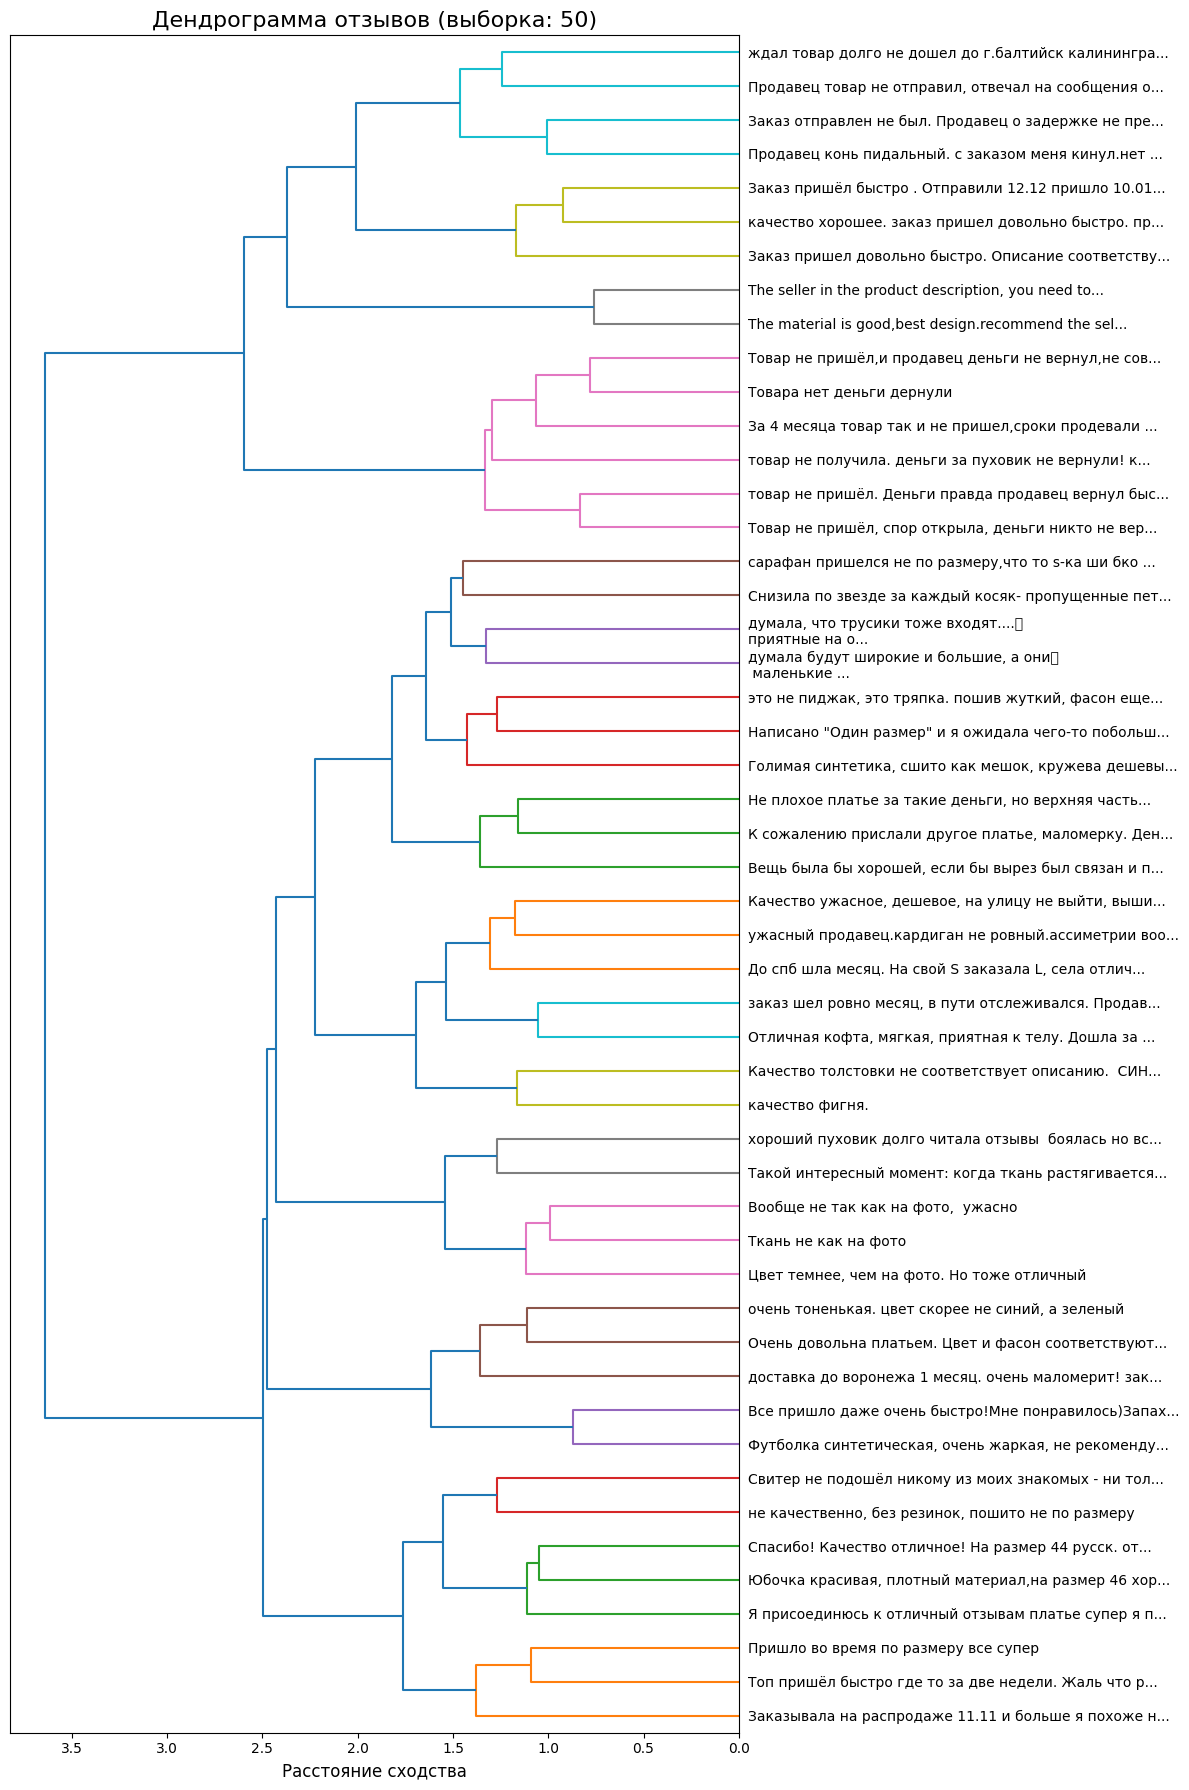

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Сокращение текста отзыва для красивого отображения на графике
labels_short = [
    (str(r)[:50] + '...') if len(str(r)) > 50 else str(r) 
    for r in df.loc[sample_indices, 'review']
]
# Визуализация 
plt.figure(figsize=(12, 18))
Z = linkage(dist_matrix, method='ward')

dendrogram(
    Z,
    labels=labels_short,
    orientation='left',
    leaf_font_size=10,
    color_threshold=1.5     
)

plt.title(f'Дендрограмма отзывов (выборка: {sample_size})', fontsize=16)
plt.xlabel('Расстояние сходства', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Проверка версий библиотек для requirements.txt

print(f"scikit-learn: {sklearn.__version__}")
print(f"pymorphy3: {pymorphy3.__version__}")
import numpy as np
import pandas as pd
import re
import nltk
import string
nltk.download('punkt')
nltk.download('stopwords')
